# Zepto Sales Data Analysis Project

## Dataset Description

1.  `zepto_sales.csv`: Contains individual sales transactions.
2.  `zepto_products.csv`: Contains details about the products sold.

### `zepto_sales.csv` Columns:

*   `order_id`: Unique identifier for each order.
*   `order_date`: Date and time of the order.
*   `product_id`: Identifier for the product sold in the transaction.
*   `quantity`: Number of units of the product sold.
*   `city`: City where the order was placed.
*   `delivery_status`: Status of the delivery (e.g., Delivered, Cancelled, Returned).
*   `customer_id`: Unique identifier for the customer.
*   `delivery_time_mins`: Time taken for delivery in minutes.
*   `total_amount`: Total amount of the transaction.

### `zepto_products.csv` Columns:

*   `product_id`: Unique identifier for the product.
*   `product_name`: Name of the product.
*   `category`: Category of the product.
*   `base_price`: Base price of the product.

Let's get started!

## Step 1: Load and Initial Exploration

I have used the following Pandas methods:

*   `pd.read_csv()`: To load data from CSV files.
*   `.info()`: To get a concise summary of the DataFrame, including data types and non-null values.
*   `.describe()`: To generate descriptive statistics of numerical columns.
*   `.shape`: To get the number of rows and columns.
*   `.head()`: To view the first few rows of the DataFrame.
*   `.tail()`: To view the last few rows of the DataFrame.

In [2]:
import pandas as pd

# Load the datasets
df_sales = pd.read_csv("/content/zepto_sales (1).csv")
df_products = pd.read_csv("/content/zepto_products (1).csv")

# Display basic information for sales data
print("--- Sales Data Info ---")
df_sales.info()
print("--- Sales Data Description ---")
print(df_sales.describe())
print("--- Sales Data Shape ---")
print(df_sales.shape)
print("--- Sales Data Head ---")
print(df_sales.head())
print("--- Sales Data Tail ---")
print(df_sales.tail())

# Display basic information for products data
print("--- Products Data Info ---")
df_products.info()
print("--- Products Data Description ---")
print(df_products.describe())
print("--- Products Data Head ---")
print(df_products.head())

--- Sales Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220220 entries, 0 to 220219
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            220220 non-null  int64  
 1   order_date          220220 non-null  object 
 2   product_id          220220 non-null  int64  
 3   quantity            220220 non-null  int64  
 4   city                219118 non-null  object 
 5   delivery_status     219118 non-null  object 
 6   customer_id         220220 non-null  int64  
 7   delivery_time_mins  215817 non-null  float64
 8   total_amount        220220 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 15.1+ MB
--- Sales Data Description ---
            order_id     product_id       quantity    customer_id  \
count  220220.000000  220220.000000  220220.000000  220220.000000   
mean   152325.652429     119.214218       1.548633   60016.100023   
std     30172.2

## Step 2: Data Cleaning - Handling Missing Values and Duplicates

Real-world datasets are rarely perfect; they often contain missing values (NaN) and duplicate entries that can skew our analysis. This step focuses on identifying and rectifying these common data quality issues.

**Handling Missing Values:**

*   For the `city` and `delivery_status` columns, I will remove the records (rows) that contain `NaN` values. This is a common strategy when the missing data is a small percentage and cannot be reliably imputed, or when the missingness itself might indicate an issue.
*   For the `delivery_time_mins` column, I will fill missing values with the mean of the column. Imputation with the mean is suitable for numerical data when the missingness is assumed to be random and the mean is a representative central tendency.

**Handling Duplicate Records:**

* I will identify and remove any entirely duplicate rows in the sales data. Duplicate records can lead to overcounting and biased statistics, so it's important to ensure each observation is unique.

Finally, I will convert the `order_date` column to a proper datetime format, which is essential for time-series analysis.

In [3]:
# Check for null values in sales data
print("--- Null Values in Sales Data (Before Cleaning) ---")
print(df_sales.isnull().sum())

# Handle null values in 'city' and 'delivery_status' by dropping rows
df_sales.dropna(subset=["city", "delivery_status"], inplace=True)
print("Nulls after dropping rows in city/delivery_status:")
print(df_sales[["city", "delivery_status"]].isnull().sum())

# Handle null values in 'delivery_time_mins' by filling with the mean
# Calculate mean AFTER dropping rows, to ensure it's based on cleaned data
mean_delivery_time = df_sales["delivery_time_mins"].mean()
df_sales["delivery_time_mins"].fillna(mean_delivery_time, inplace=True)
print("Nulls after filling mean in delivery_time_mins:")
print(df_sales["delivery_time_mins"].isnull().sum())

# Check for duplicate records
print("--- Duplicate Records in Sales Data ---")
print(f"Number of duplicate rows: {df_sales.duplicated().sum()}")

# Remove duplicate records
df_sales.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {df_sales.shape[0]}")

# Convert 'order_date' to datetime objects
df_sales["order_date"] = pd.to_datetime(df_sales["order_date"])
print("--- Data Types After Cleaning and Conversion ---")
df_sales.info()

--- Null Values in Sales Data (Before Cleaning) ---
order_id                 0
order_date               0
product_id               0
quantity                 0
city                  1102
delivery_status       1102
customer_id              0
delivery_time_mins    4403
total_amount             0
dtype: int64
Nulls after dropping rows in city/delivery_status:
city               0
delivery_status    0
dtype: int64
Nulls after filling mean in delivery_time_mins:
0
--- Duplicate Records in Sales Data ---


/tmp/ipykernel_1746/2969825063.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_sales["delivery_time_mins"].fillna(mean_delivery_time, inplace=True)


Number of duplicate rows: 216
Number of rows after removing duplicates: 217806
--- Data Types After Cleaning and Conversion ---
<class 'pandas.core.frame.DataFrame'>
Index: 217806 entries, 0 to 220219
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            217806 non-null  int64         
 1   order_date          217806 non-null  datetime64[ns]
 2   product_id          217806 non-null  int64         
 3   quantity            217806 non-null  int64         
 4   city                217806 non-null  object        
 5   delivery_status     217806 non-null  object        
 6   customer_id         217806 non-null  int64         
 7   delivery_time_mins  217806 non-null  float64       
 8   total_amount        217806 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 16.6+ MB


## Step 3: Data Analysis - Aggregations and Grouping

With our data cleaned, we can now start extracting meaningful insights. This step involves performing various aggregations and grouping operations using Pandas to answer specific business questions about Zepto's sales performance.

I have covered:

*   **Summary Statistics**: Calculating minimum, maximum, and average values for key metrics.
*   **Top Performers**: Identifying the best-selling products and cities by total sales amount.
*   **Trends**: Analyzing sales patterns over time (e.g., monthly sales).
*   **Categorical Breakdown**: Understanding sales distribution across different product categories and cities.

These operations are fundamental to understanding the underlying patterns and drivers within your dataset.

In [4]:
# Find min, max, and average total amount
min_amount = df_sales["total_amount"].min()
max_amount = df_sales["total_amount"].max()
avg_amount = df_sales["total_amount"].mean()
print(f"Min Total Amount: {min_amount:.2f}")
print(f"Max Total Amount: {max_amount:.2f}")
print(f"Average Total Amount: {avg_amount:.2f}")

# Top 5 products by total sales amount
top_products = df_sales.groupby("product_id")["total_amount"].sum().nlargest(5)
print("--- Top 5 Products by Sales Amount ---")
print(top_products)

# Merge with product details to get product names
top_products_details = top_products.reset_index().merge(df_products, on="product_id")
print("--- Top 5 Products by Sales Amount (with names) ---")
print(top_products_details[["product_name", "category", "total_amount"]])

# Total sales by city
sales_by_city = df_sales.groupby("city")["total_amount"].sum().sort_values(ascending=False)
print("--- Total Sales by City ---")
print(sales_by_city)

# Average delivery time by city
avg_delivery_time_by_city = df_sales.groupby("city")["delivery_time_mins"].mean().sort_values()
print("--- Average Delivery Time by City (minutes) ---")
print(avg_delivery_time_by_city)

# Sales trend over time (e.g., monthly sales)
df_sales["month"] = df_sales["order_date"].dt.to_period("M")
monthly_sales = df_sales.groupby("month")["total_amount"].sum()
print("--- Monthly Sales Trend ---")
print(monthly_sales)

# Sales by product category
sales_by_category = df_sales.merge(df_products, on="product_id")
sales_by_category = sales_by_category.groupby("category")["total_amount"].sum().sort_values(ascending=False)
print("--- Total Sales by Product Category ---")
print(sales_by_category)

Min Total Amount: 23.25
Max Total Amount: 2656.85
Average Total Amount: 302.32
--- Top 5 Products by Sales Amount ---
product_id
134    11658720.91
112     7908234.46
135     6171994.29
129     4796676.99
131     4716913.11
Name: total_amount, dtype: float64
--- Top 5 Products by Sales Amount (with names) ---
    product_name              category  total_amount
0       Handwash         Personal Care   11658720.91
1    Paneer 200g          Dairy & Eggs    7908234.46
2     Toothpaste         Personal Care    6171994.29
3  Detergent 1kg  Household Essentials    4796676.99
4   Toilet Paper  Household Essentials    4716913.11
--- Total Sales by City ---
city
Mumbai       23063075.50
Bangalore    16385777.49
Delhi         9937151.01
Hyderabad     5305224.53
Pune          4559465.47
Kolkata       2671042.99
Chennai       2563667.49
Ahmedabad     1362556.30
Name: total_amount, dtype: float64
--- Average Delivery Time by City (minutes) ---
city
Hyderabad    25.914055
Mumbai       25.979052
Bang

## Step 4: Data Visualization with Matplotlib & Seaborn

Data visualization is a powerful way to communicate insights from your analysis. In this step, I have used Matplotlib and Seaborn to create a comprehensive set of charts that visually represent the findings from my data analysis.

I have created a 3x3 grid of 9 diverse plots to showcase different aspects of the Zepto sales data.

**Charts generated:**

1.  **Line Chart**: Monthly Sales Trend
2.  **Bar Chart**: Total Sales by City
3.  **Pie Chart**: Sales by Product Category
4.  **Histogram**: Distribution of Delivery Times
5.  **Scatter Plot**: Quantity vs. Total Amount
6.  **Count Plot**: Delivery Status Distribution
7.  **Box Plot**: Delivery Time by City
8.  **Bar Plot**: Top 5 Products by Quantity Sold
9.  **Heatmap**: Sales by City and Month



/tmp/ipykernel_1746/2193430274.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_city.index, y=sales_by_city.values, palette='magma', ax=axes[0, 1])
/tmp/ipykernel_1746/2193430274.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='delivery_status', data=df_sales, palette='deep', ax=axes[1, 2])
/tmp/ipykernel_1746/2193430274.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y='delivery_time_mins', data=df_sales, palette='coolwarm', ax=axes[2, 0])
/tmp/ipykernel_1746/2193430274.py:58: FutureWarning: 

Passing 

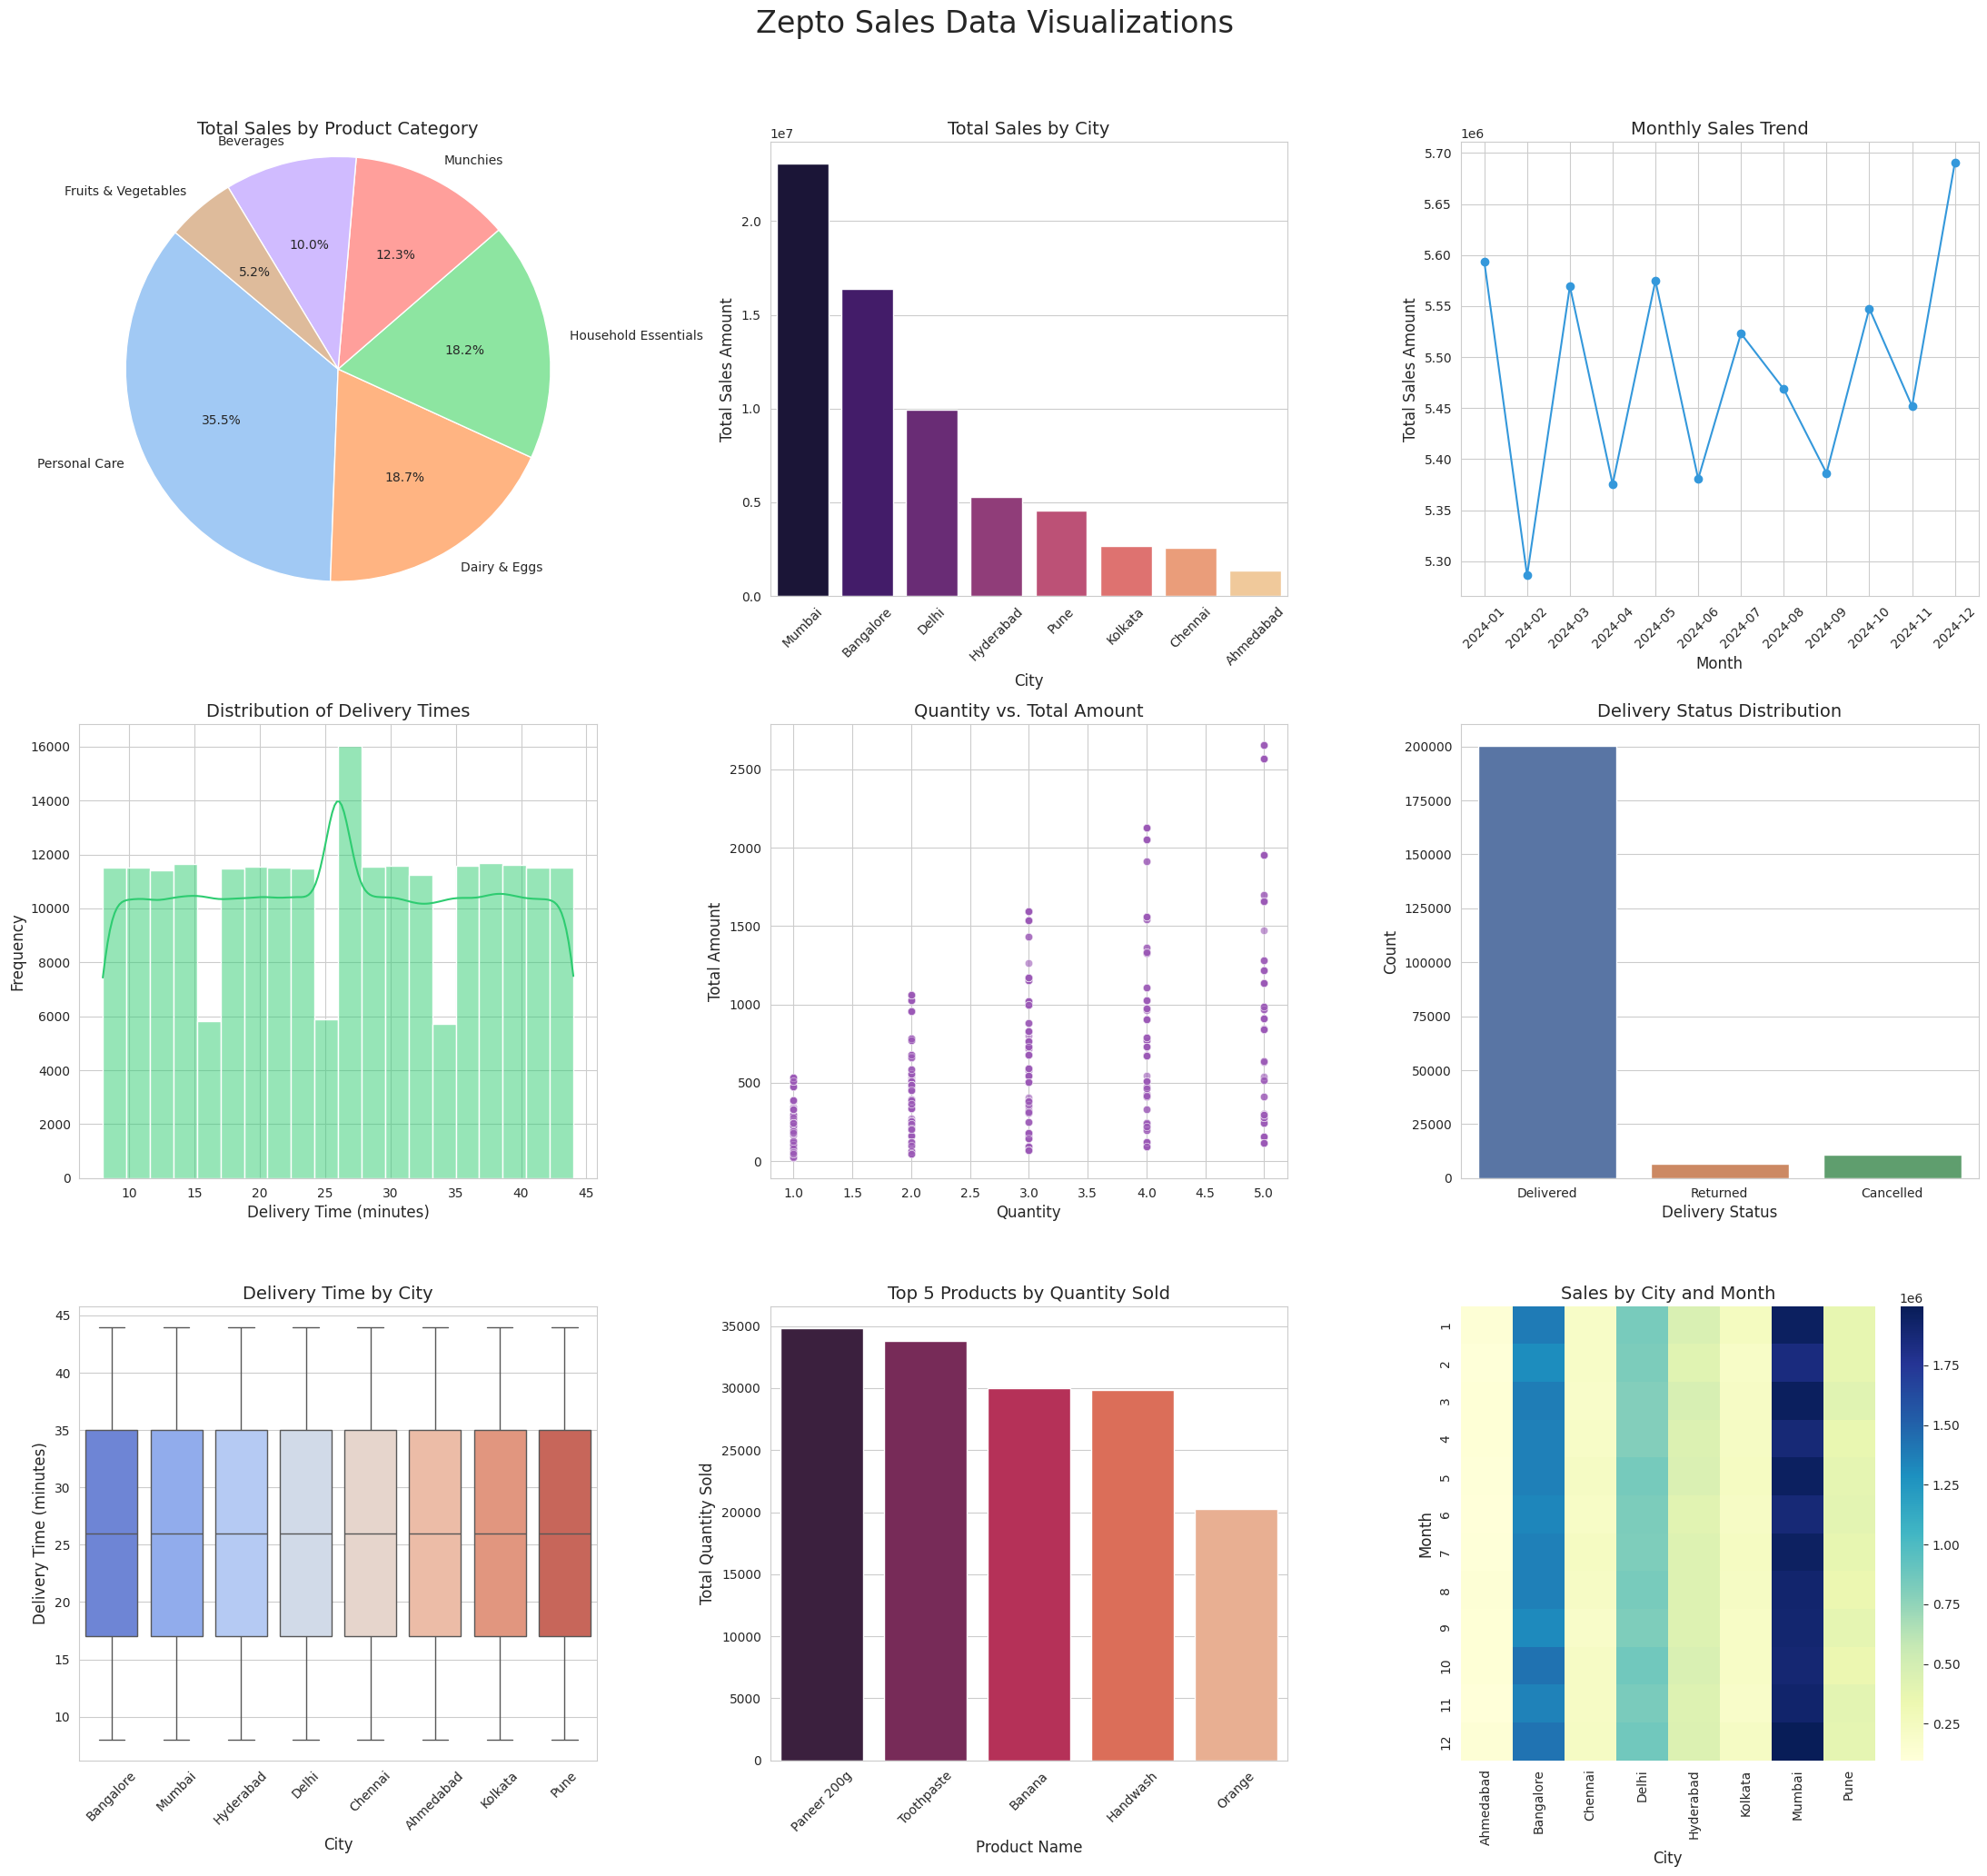

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Create a 3x3 subplot grid
fig, axes = plt.subplots(3, 3, figsize=(22, 20))
fig.suptitle("Zepto Sales Data Visualizations", fontsize=24, y=1.03)

# Plot 1: Monthly Sales Trend (Line Chart)
axes[0, 2].plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o', color='#3498DB')
axes[0, 2].set_title('Monthly Sales Trend', fontsize=14)
axes[0, 2].set_xlabel('Month', fontsize=12)
axes[0, 2].set_ylabel('Total Sales Amount', fontsize=12)
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(True)

# Plot 2: Total Sales by City (Bar Chart)
sns.barplot(x=sales_by_city.index, y=sales_by_city.values, palette='magma', ax=axes[0, 1])
axes[0, 1].set_title('Total Sales by City', fontsize=14)
axes[0, 1].set_xlabel('City', fontsize=12)
axes[0, 1].set_ylabel('Total Sales Amount', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Sales by Product Category (Pie Chart)
axes[0, 0].pie(sales_by_category, labels=sales_by_category.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[0, 0].set_title('Total Sales by Product Category', fontsize=14)
axes[0, 0].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Plot 4: Distribution of Delivery Times (Histogram)
sns.histplot(df_sales['delivery_time_mins'], bins=20, kde=True, color='#2ECC71', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Delivery Times', fontsize=14)
axes[1, 0].set_xlabel('Delivery Time (minutes)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)

# Plot 5: Quantity vs. Total Amount (Scatter Plot)
sns.scatterplot(x='quantity', y='total_amount', data=df_sales.sample(n=5000), alpha=0.6, color='#9B59B6', ax=axes[1, 1]) # Sample for performance
axes[1, 1].set_title('Quantity vs. Total Amount', fontsize=14)
axes[1, 1].set_xlabel('Quantity', fontsize=12)
axes[1, 1].set_ylabel('Total Amount', fontsize=12)

# Plot 6: Delivery Status Distribution (Count Plot)
sns.countplot(x='delivery_status', data=df_sales, palette='deep', ax=axes[1, 2])
axes[1, 2].set_title('Delivery Status Distribution', fontsize=14)
axes[1, 2].set_xlabel('Delivery Status', fontsize=12)
axes[1, 2].set_ylabel('Count', fontsize=12)

# Plot 7: Delivery Time by City (Box Plot)
sns.boxplot(x='city', y='delivery_time_mins', data=df_sales, palette='coolwarm', ax=axes[2, 0])
axes[2, 0].set_title('Delivery Time by City', fontsize=14)
axes[2, 0].set_xlabel('City', fontsize=12)
axes[2, 0].set_ylabel('Delivery Time (minutes)', fontsize=12)
axes[2, 0].tick_params(axis='x', rotation=45)

# Plot 8: Top 5 Products by Quantity Sold (Bar Plot)
top_products_qty = df_sales.groupby('product_id')['quantity'].sum().nlargest(5).reset_index()
top_products_qty = top_products_qty.merge(df_products, on='product_id')
sns.barplot(x='product_name', y='quantity', data=top_products_qty, palette='rocket', ax=axes[2, 1])
axes[2, 1].set_title('Top 5 Products by Quantity Sold', fontsize=14)
axes[2, 1].set_xlabel('Product Name', fontsize=12)
axes[2, 1].set_ylabel('Total Quantity Sold', fontsize=12)
axes[2, 1].tick_params(axis='x', rotation=45)

# Plot 9: Sales by City and Month (Heatmap)
sales_city_month = df_sales.groupby([df_sales['order_date'].dt.month, 'city'])['total_amount'].sum().unstack(fill_value=0)
sns.heatmap(sales_city_month, cmap='YlGnBu', ax=axes[2, 2])
axes[2, 2].set_title('Sales by City and Month', fontsize=14)
axes[2, 2].set_xlabel('City', fontsize=12)
axes[2, 2].set_ylabel('Month', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()